<a href="https://colab.research.google.com/github/AnshulKumar79/Neer_Nirikshan_Hackathon_Project/blob/main/Neer_Nirikshan_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="FEfRg2eZ9m7JuSwTfuAY")
project = rf.workspace("project-mfzoq").project("potholes-detection-yolov8-rtu6b")
version = project.version(1)
dataset = version.download("yolov8")

print(f"Dataset downloaded to: {dataset.location}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 119.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Potholes-Detection-Yolov8-1 in yolov8:: 100%|██████████| 8006/8006 [00:01<00:00, 6364.66it/s]


Dataset downloaded to: /content/Potholes-Detection-Yolov8-1


In [ ]:
# Look at the contents of the data.yaml file
!cat {dataset.location}/data.yaml

names:
- pothole
nc: 1
roboflow:
  license: CC BY 4.0
  project: potholes-detection-yolov8-rtu6b
  url: https://universe.roboflow.com/project-mfzoq/potholes-detection-yolov8-rtu6b/dataset/1
  version: 1
  workspace: project-mfzoq
test: ../test/images
train: ../train/images
val: ../valid/images


In [ ]:
import yaml
import os

# Defining the absolute paths to our dataset
dataset_path = dataset.location

data = {
    'train': os.path.join(dataset_path, 'train/images'),
    'val': os.path.join(dataset_path, 'valid/images'),
    'test': os.path.join(dataset_path, 'test/images'),
    'nc': 1,
    'names': ['pothole'] #class_name
}


yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(yaml_path, 'w') as outfile:
    yaml.dump(data, outfile, default_flow_style=False)

print(f"Updated {yaml_path} successfully!")

Updated /content/Potholes-Detection-Yolov8-1/data.yaml successfully!


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

# Loading the pre-trained YOLOv8 Nano model
model = YOLO('yolov8n.pt')

print("Base model loaded. Ready to train on pothole dataset!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Base model loaded. Ready to train on pothole dataset!


In [ ]:
# results = model.train(
#     data=f"{dataset.location}/data.yaml", #The path to our Roboflow data
#     epochs=50,                            #No. of training rounds
#     imgsz=640,                            #Standard image size for YOLO
#     plots=True                            #Generates charts so we can see progress
# )

In [ ]:

print("Mobile-Optimized Training...")

results = model.train(
    data=yaml_path,        # Points to your data.yaml file
    epochs=100,            # Max epochs
    patience=15,           # Early stopping: Stops if it doesn't improve for 15 rounds
    imgsz=416,             # THE FIX: Shrunk from 640 to 416 for faster Android inference
    batch=-1,              # Auto-optimizes Colab GPU RAM
    plots=True             # Saves the performance charts for your presentation
)

print("Training Completed")

Mobile-Optimized Training...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Potholes-Detection-Yolov8-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

In [ ]:
# test_images = os.listdir(f"{dataset.location}/test/images")
# sample_path = os.path.join(dataset.location, "test/images", test_images[0])

# # Run detection
# results = model.predict(source=sample_path, save=True, conf=0.5)

# print(f"Results saved! Check 'runs/detect/predict' to see the boxes.")

In [ ]:
# model.export(format='onnx')

# print("Model exported successfully!")

Calculating final validation metrics...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1661.7±478.6 MB/s, size: 61.2 KB)
val: Scanning /content/Potholes-Detection-Yolov8-1/valid/labels.cache... 800 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 223.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 6.8it/s 7.4s
                   all        800       2166      0.855      0.686      0.762      0.511
Speed: 0.7ms preprocess, 2.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val18
Awesome! Your overall mAP50-95 score is: 0.5110
Testing visual inference on: po_1581_jpg.rf.04f03e41327188c7d6cda8ea645d7230.jpg

image 1/1 /content/Potholes-Detection-Yolov8-1/test/images/po_1581_jpg.rf.04f03e41327188c7d6cda8ea645d7230.jpg: 416x416 1 pothole, 7.0ms
Speed: 2.0ms preprocess, 7.0ms 

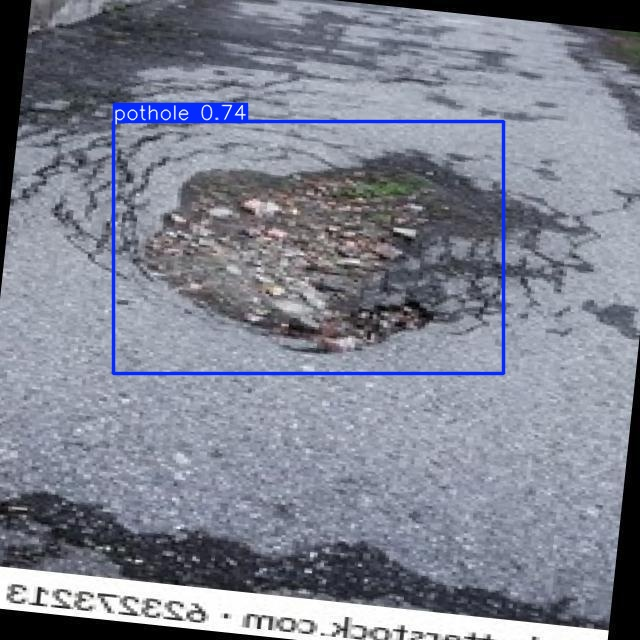

In [ ]:
from IPython.display import Image, display

print("Calculating final validation metrics...")
metrics = model.val()
print(f"Awesome! Your overall mAP50-95 score is: {metrics.box.map:.4f}")

test_images = os.listdir(f"{dataset.location}/test/images")
sample_path = os.path.join(dataset.location, "test/images", test_images[5])

print(f"Testing visual inference on: {test_images[5]}")
predict_results = model.predict(source=sample_path, save=True, conf=0.5, imgsz=416)

latest_run = max([os.path.join('runs/detect', d) for d in os.listdir('runs/detect')], key=os.path.getmtime)
saved_img_path = os.path.join(latest_run, test_images[5])

display(Image(filename=saved_img_path))

In [ ]:
best_model_path = "runs/detect/train/weights/best.pt"
final_model = YOLO(best_model_path)


print("Exporting model to INT8 TFLite")
export_path = final_model.export(
    format="tflite",
    int8=True,       # Shrinks the model for mobile speed
    imgsz=416        # Must match the training image size
)

print(f"TFLite Export Successful! File saved at: {export_path}")

Exporting model to INT8 TFLite
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 5, 3549) (5.9 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 18 packages in 7.75s
Prepared 9 packages in 4.91s
Installed 9 packages in 256ms
 + ai-edge-litert==2.1.3
 + backports-strenum==1

In [ ]:

labels_file = "labels.txt"
with open(labels_file, "w") as f:
    f.write("pothole\n")

print(f"Labels file created: {labels_file}")

Labels file created: labels.txt


In [ ]:
#Kagglehub library ko update karna
!pip install --upgrade kagglehub -q

import os
from google.colab import userdata
import kagglehub

#Token fetch karna aur agar koi space ho toh use .strip() se hatana
token = userdata.get('KAGGLE_API_TOKEN')

if token:
    os.environ["KAGGLE_API_TOKEN"] = token.strip()
    print("Token mil gaya hai! Ab Kaggle se connect kar rahe hain...")

    #Login attempt
    try:
        kagglehub.login()
        print("Login Successful!")
    except Exception as e:
        print(f"Login fail ho gaya. Error: {e}")
else:
    print("Error: Colab Secrets mein token nahi mila. Kripya naam 'KAGGLE_API_TOKEN' check karein.")

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ryukijanoramunae/pothole-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pothole-dataset' dataset.
Path to dataset files: /kaggle/input/pothole-dataset


In [7]:
import os

# Dataset folder ke andar kya kya hai, wo dekhne ke liye
print("Files/folders present in the dataset:")
files = os.listdir(path)

for file in files:
    print("-", file)

Files/folders present in the dataset:
- README.dataset.txt
- README.roboflow.txt
- data.yaml
- valid
- test
- train


In [8]:
# data.yaml file ka poora rasta (path)
yaml_path = os.path.join(path, "data.yaml")

# File ko open karke read karna
with open(yaml_path, 'r') as file:
    yaml_content = file.read()
    print(yaml_content)

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['0']

roboflow:
  workspace: project-ssayl
  project: potholes-detection-d4rma
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/project-ssayl/potholes-detection-d4rma/dataset/1


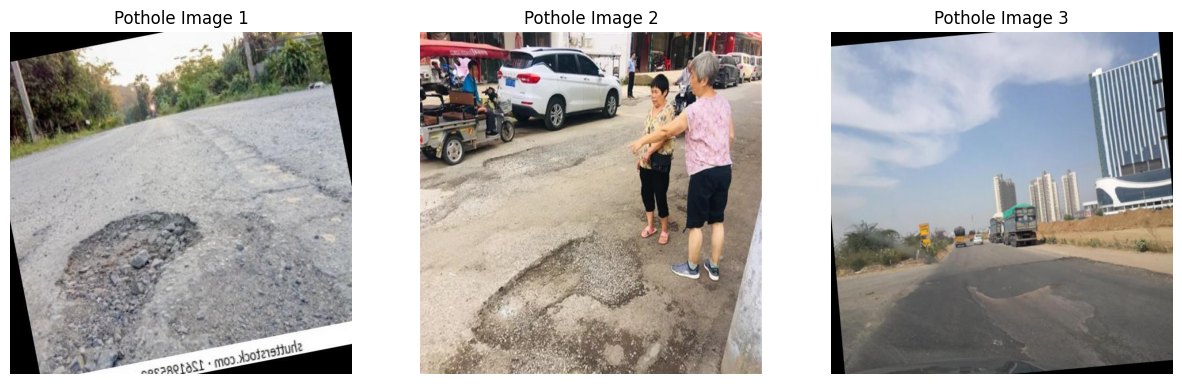

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Train images folder ka rasta (path)
train_images_path = os.path.join(path, "train", "images")

# Folder se shuruati 3 images ke naam nikalna
image_files = os.listdir(train_images_path)[:3]

# Images ko display karne ka code
plt.figure(figsize=(15, 5)) # Image ka size set kar rahe hain

for i, img_name in enumerate(image_files):
    img_path = os.path.join(train_images_path, img_name)
    img = mpimg.imread(img_path) # Image ko read karna

    plt.subplot(1, 3, i+1) # 3 images ko ek line mein lagana
    plt.imshow(img)
    plt.title(f"Pothole Image {i+1}")
    plt.axis('off') # Borders/Axis hatana

plt.show()

In [10]:
# YOLO library ko install karna
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.0 MB/s eta 0:00:00


In [11]:
#starting training again with 10 epochs
from ultralytics import YOLO
import os

# Aapki data.yaml file ka exact rasta (path)
yaml_path = os.path.join(path, "data.yaml")

# Hum YOLOv8 ka Nano model ('yolov8n.pt') use kar rahe hain kyunki ye fast hota hai
model = YOLO("yolov8n.pt")

print("Training shuru ho rahi hai... Isme thoda time lag sakta hai!")

# Training start karna (epochs=10 ka matlab hai model dataset ko 10 baar padhega)
results = model.train(data=yaml_path, epochs=10, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Training shuru ho rahi hai... Isme thoda time lag sakta hai!
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/pothole-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, fr

TESTING

image 1/1 /kaggle/input/pothole-dataset/test/images/781_png_jpg.rf.201f1a5c79a801369dac5a6000433acb.jpg: 640x640 12 0s, 7.2ms
Speed: 1.8ms preprocess, 7.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


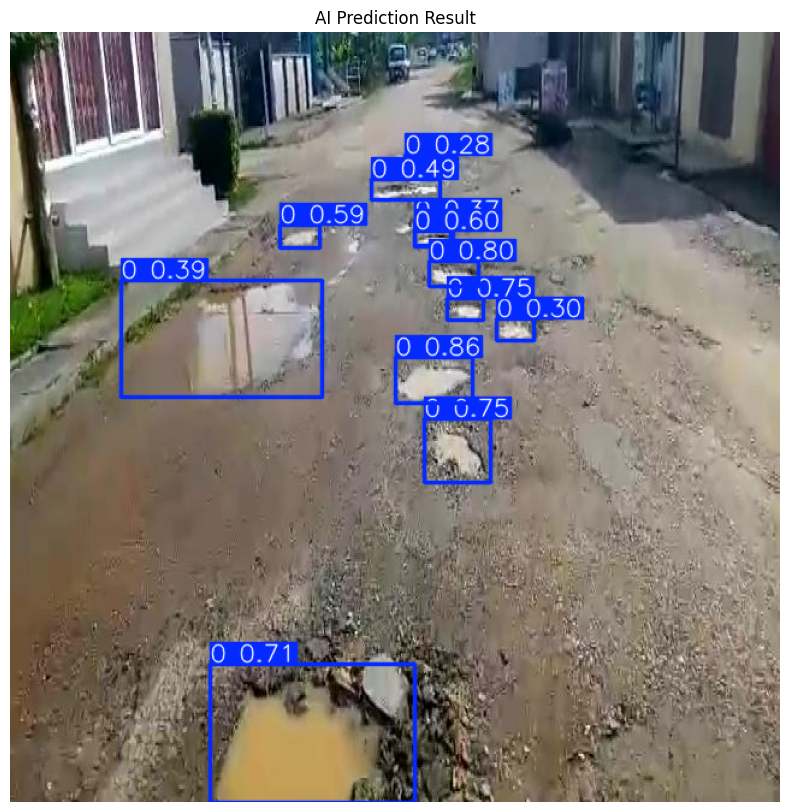

In [12]:

import cv2

#Apna naya train kiya hua model load
model_path = "runs/detect/train/weights/best.pt"
my_ai_model = YOLO(model_path)

#Test folder se pehli image ka rasta nikalna
test_images_path = os.path.join(path, "test", "images")
test_img_name = os.listdir(test_images_path)[0] # Pehli image
test_img_full_path = os.path.join(test_images_path, test_img_name)

print("TESTING")

#Model se prediction
results = my_ai_model(test_img_full_path)

#Result (Bounding boxes) wali image display karna
res_plotted = results[0].plot()
res_plotted_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB) # Image colors ko theek karna

plt.figure(figsize=(10, 10))
plt.imshow(res_plotted_rgb)
plt.title("AI Prediction Result")
plt.axis('off')
plt.show()

In [13]:
#Exporting to .tflite file format for app


from google.colab import files

#Apna trained YOLO model loading
model = YOLO("runs/detect/train/weights/best.pt")
#Model ko TFLite format mein export karna
tflite_model_path = model.export(format="tflite")

print(f"Conversion successful! File yahan save hui hai: {tflite_model_path}")
print("Downloading...")


files.download(tflite_model_path)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 2.95s
Prepared 9 packages in 6.93s
Installed 9 packages in 477ms
 + ai-edge-litert==2.1.3
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + onnx==1.21.0
 + onnx-graphsurgeon==0.6.1
 + onnx2tf==1.28.8
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from google.colab import files

# best.pt file ko seedha PC mein download karte hain
files.download('runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>